In [1]:
from m_star_predictor import (
    LinearRegression, FCNN, fit_model
)

from utility import (
    normalize, real_units, reduce_dataset, compute_rmse, MStarPredictorConfig,
    get_predictions
)

import torch
import torch.utils.data as Data
from torch.utils.data import random_split
from torch import optim
import numpy as np
import os
import json

import pandas as pd

import matplotlib.pyplot as plt

In [13]:
predictor_name = "predictor_12"
predictor_dir = os.path.join("m_star_predictors", predictor_name)
config_json_path = os.path.join(predictor_dir, "config.json")

with open(config_json_path, "r") as f:
    config_dict = json.load(f)

config = MStarPredictorConfig(**config_dict)

In [14]:
# Ensuring reproducibility
np.random.seed(config.random_state)
torch.manual_seed(config.random_state);
sklear_random_state = config.random_state

In [15]:
fcnn_train_traj = config.train_loss_trajectory
fcnn_test_traj = config.test_loss_trajectory
fcnn_name = ""

Text(0.5, 0, 'Epoch')

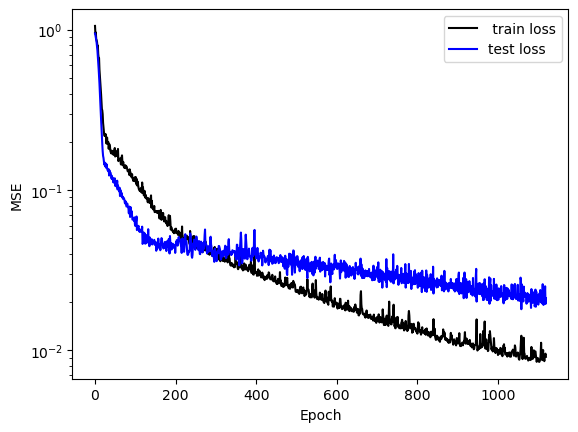

In [16]:
plt.plot(fcnn_train_traj, color="black", label=f" train loss")
plt.plot(fcnn_test_traj, color="blue", label=f"test loss")
plt.gca().set_yscale("log")
plt.legend()
plt.ylabel("MSE")
plt.xlabel("Epoch")

In [17]:
config.dataset_name

'ePBL_paper_expanded_2283_corrected'

In [ ]:
data_directory = '../m_star_dataset'

dataset_name = config.dataset_name
validation_dataset_name = config.validation_dataset_name

data = pd.read_csv(os.path.join(data_directory, f"{config.dataset_filename}.csv"))
validation_data = pd.read_csv(os.path.join(data_directory, f"{config.validation_dataset_filename}.csv"))

In [20]:
with open(os.path.join(data_directory, f'{dataset_name}_training_set_cases.json'), 'r') as file:
    gotm_case_dict = json.load(file)

with open(os.path.join(data_directory, f'{validation_dataset_name}_training_set_cases.json'), 'r') as file:
    gotm_validation_case_dict = json.load(file)

In [21]:
X, y, X_val, y_val, fcnn_prediction, fcnn_prediction_val = get_predictions(
    training_data=data,
    validation_data=validation_data,
    config=config
)

In [22]:
config.rmse

8.888504225978977e-07

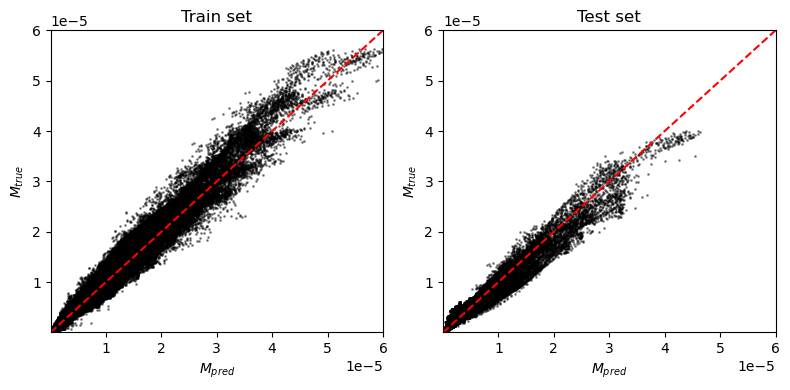

In [23]:
xs, ys = np.linspace(0., 6e-3, 1000), np.linspace(0., 6e-3, 1000)

fig, ax = plt.subplots(1,2,figsize=(8,4))
ax[0].scatter(fcnn_prediction.detach().numpy(), y, color="black", s=1, alpha=.4)
ax[0].plot(xs, ys, color="red", linestyle="dashed")
ax[0].set_ylabel("$M_{true}$")
ax[0].set_xlabel("$M_{pred}$")
ax[0].set_title("Train set")

ax[1].scatter(fcnn_prediction_val.detach().numpy(), y_val, color="black", s=1, alpha=.4)
ax[1].plot(xs, ys, color="red", linestyle="dashed")
ax[1].set_ylabel("$M_{true}$")
ax[1].set_xlabel("$M_{pred}$")
ax[1].set_title("Test set")

# fig.suptitle(f"Train and test predictions for {name_1}")

for a in ax:
    # a.set_xscale("log")
    # a.set_yscale("log")
    a.set_xlim(1e-10, 6e-5)
    a.set_ylim(1e-10, 6e-5)

fig.tight_layout()

# plt.savefig(f"inst_M_true_pred_{name_1}.png", dpi=300)

In [216]:
fcnn_pred_diff = fcnn_prediction_val.detach().numpy()[1:] - fcnn_prediction_val.detach().numpy()[:-1]
y_val_diff = y_val[1:] - y_val[:-1]

In [221]:
fcnn_pred_init = []
y_val_diff_init = []

for i in range(200,300):
    fcnn_pred_init.append(fcnn_pred_diff[i::config.n_time_steps])
    y_val_diff_init.append(y_val_diff[i::config.n_time_steps])

In [222]:
fcnn_pred_init = [item for sublist in fcnn_pred_init for item in sublist]

In [223]:
y_val_diff_init = [item for sublist in y_val_diff_init for item in sublist]

In [243]:
X_val.detach().numpy()[1:,3]

array([20.866898, 24.994547, 28.995445, ..., 89.99941 , 90.54438 ,
       90.88166 ], dtype=float32)

In [27]:
config.n_time_steps = 431

In [271]:
config.feature_names

['f', 'u_star', 'B', 'bl_tke', 'M_i-1']

In [275]:
Ekman_depth = X_val.detach().numpy()[1:,1]/X_val.detach().numpy()[1:,0]

In [282]:
len(X_val.detach().numpy()[1:,2][X_val.detach().numpy()[1:,3]<25])

462

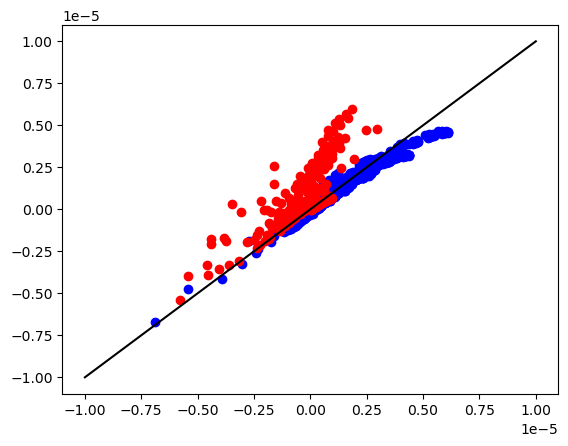

In [285]:
criterion = np.where(X_val.detach().numpy()[1:,3]<25)
criterion_o = np.where(X_val.detach().numpy()[1:,3]>25)
plt.scatter(fcnn_pred_diff[criterion_o], y_val_diff[criterion_o], color="blue")
plt.scatter(fcnn_pred_diff[criterion], y_val_diff[criterion], color="red")
x, y = np.linspace(-1e-5, 1e-5, 1000), np.linspace(-1e-5, 1e-5, 1000)

# plt.gca().set_xscale("log")
# plt.gca().set_yscale("log")
# plt.xlim(1e-12, 5e-5)
# plt.ylim(1e-12, 5e-5)

plt.plot(x, y, color="black")

/tmp/ipykernel_380108/3616274646.py:4: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  fig, ax = plt.subplots(2,1,figsize=(10,6),tight_layout=True,sharex=True)


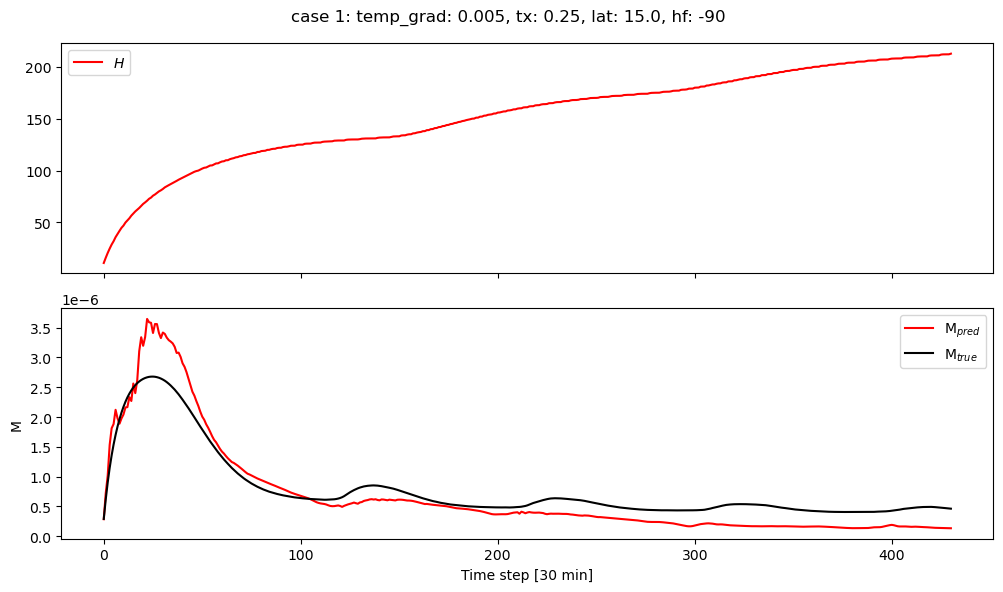

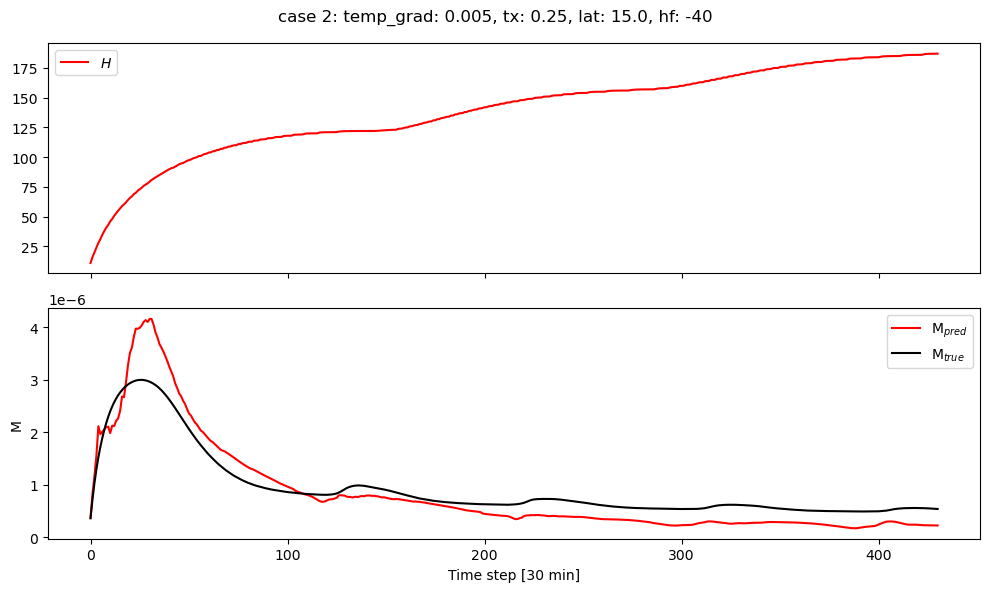

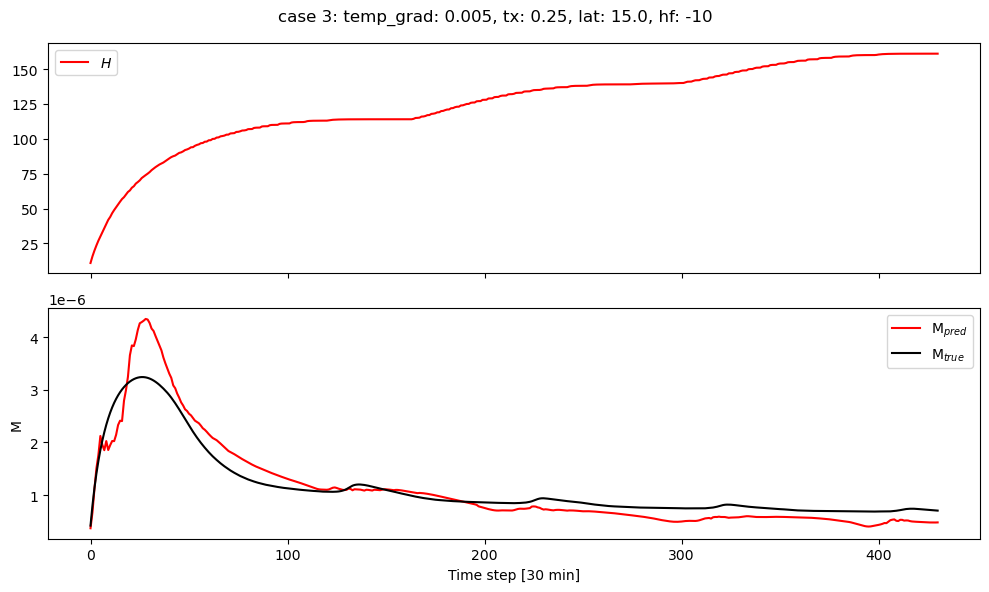

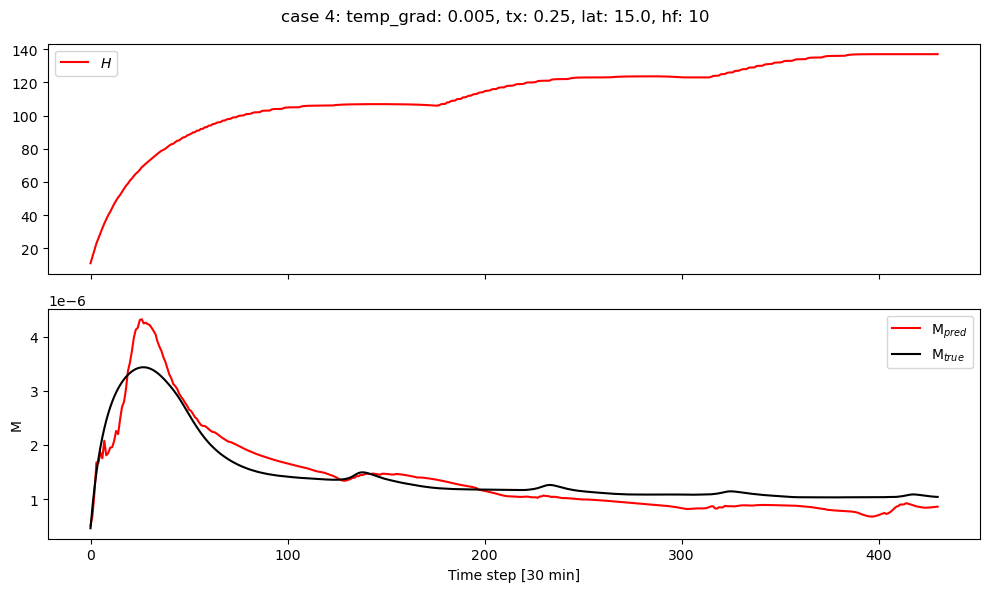

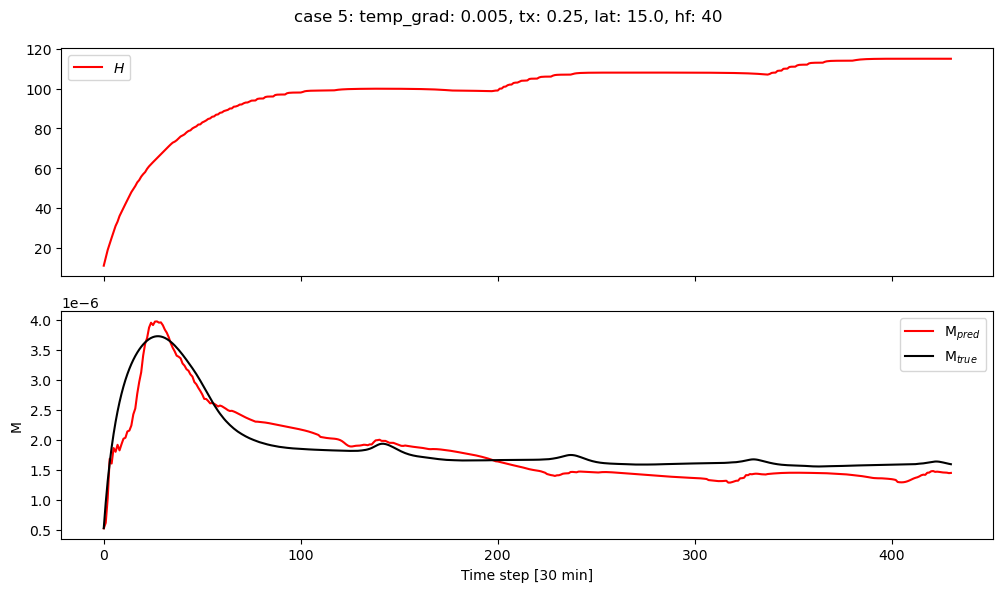

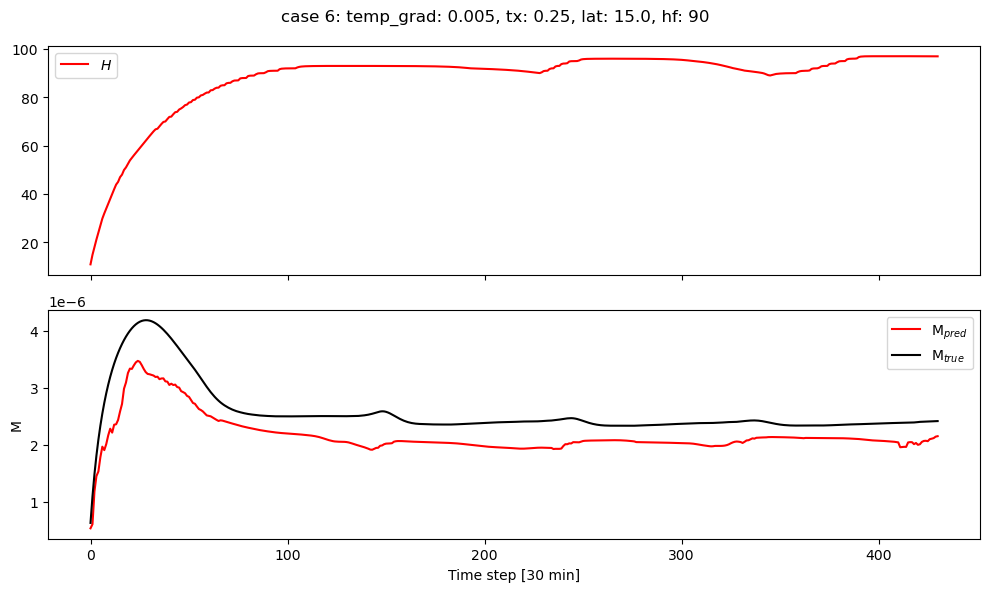

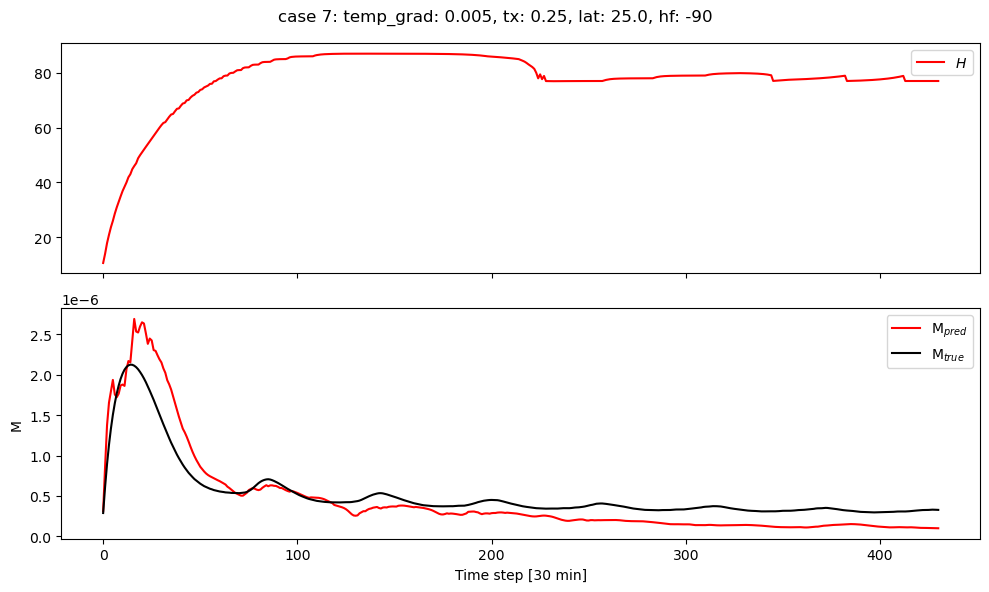

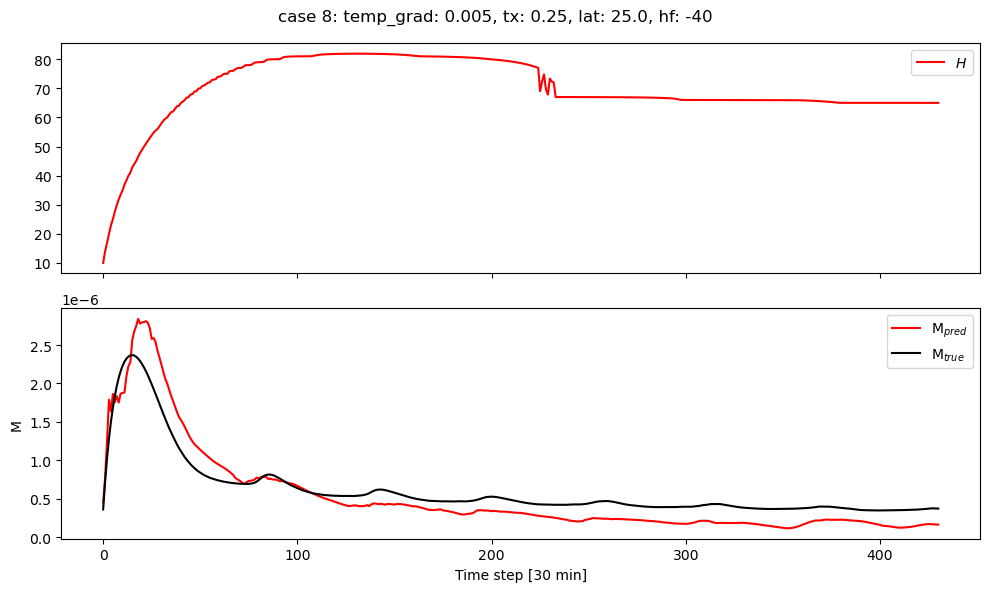

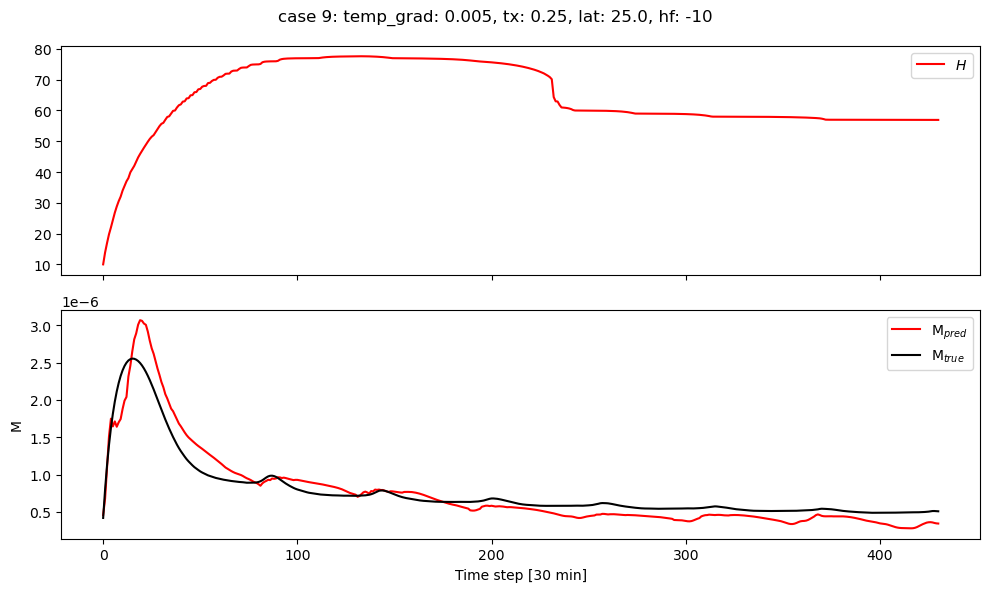

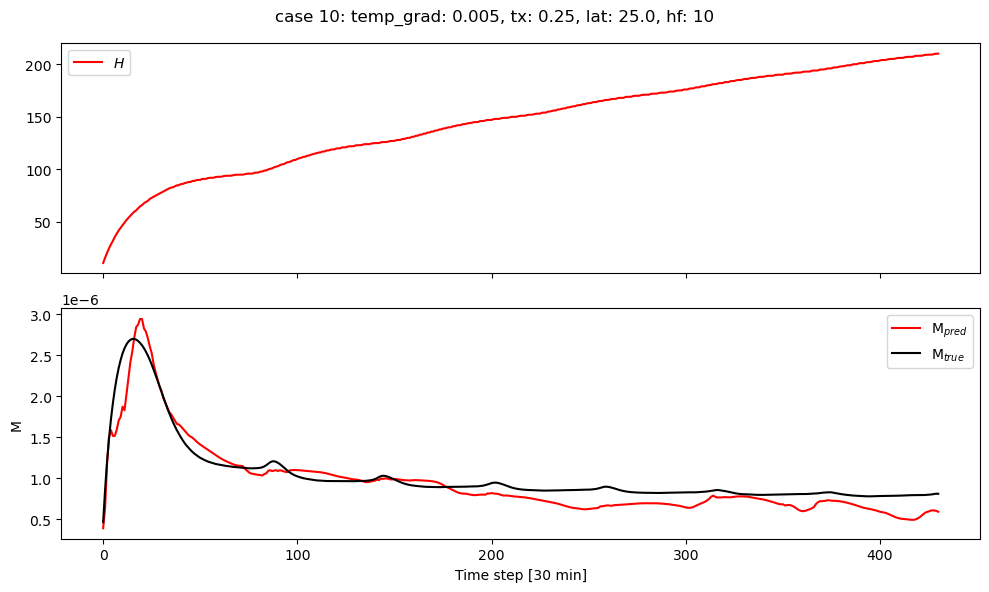

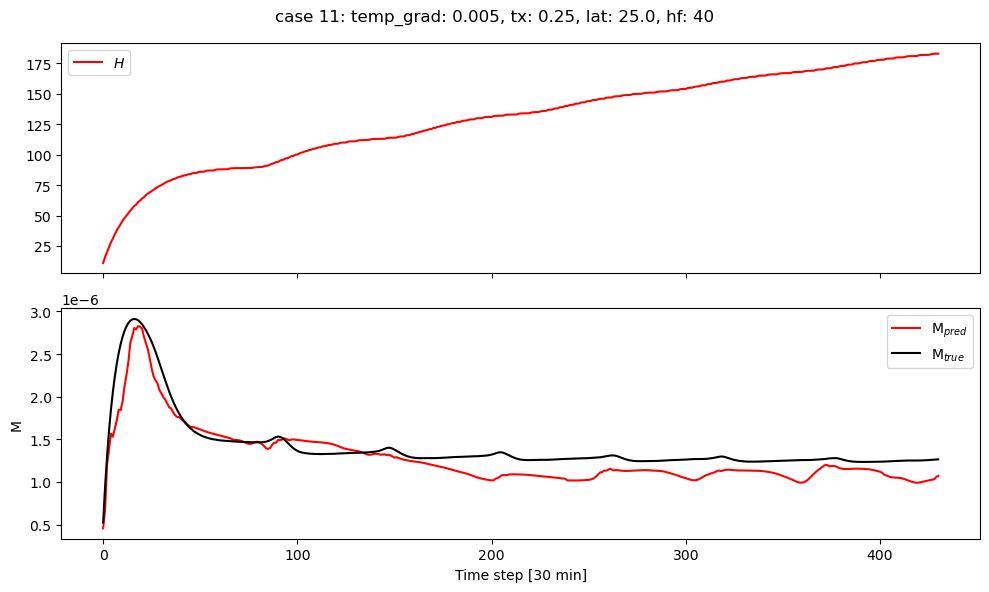

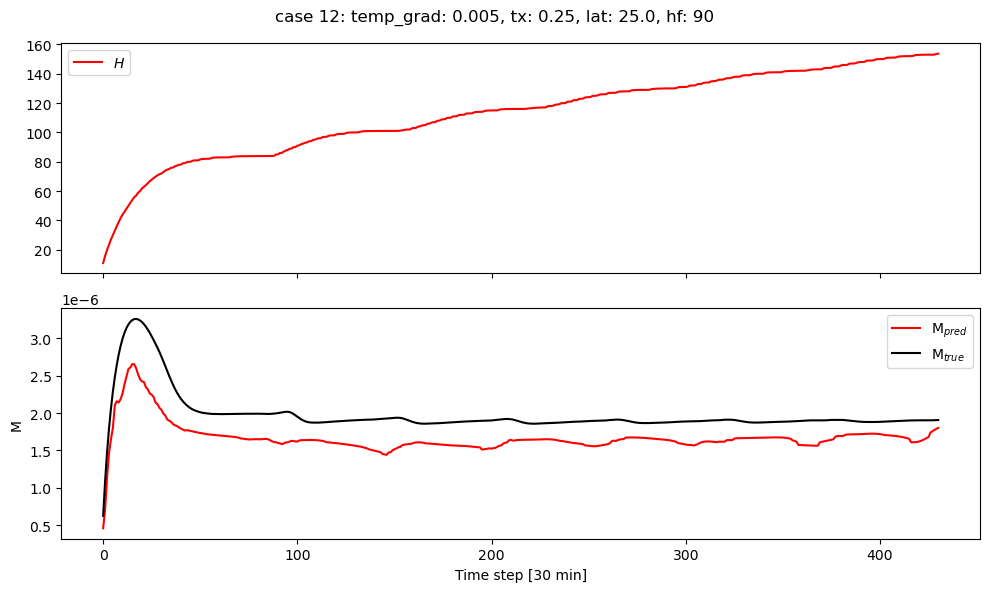

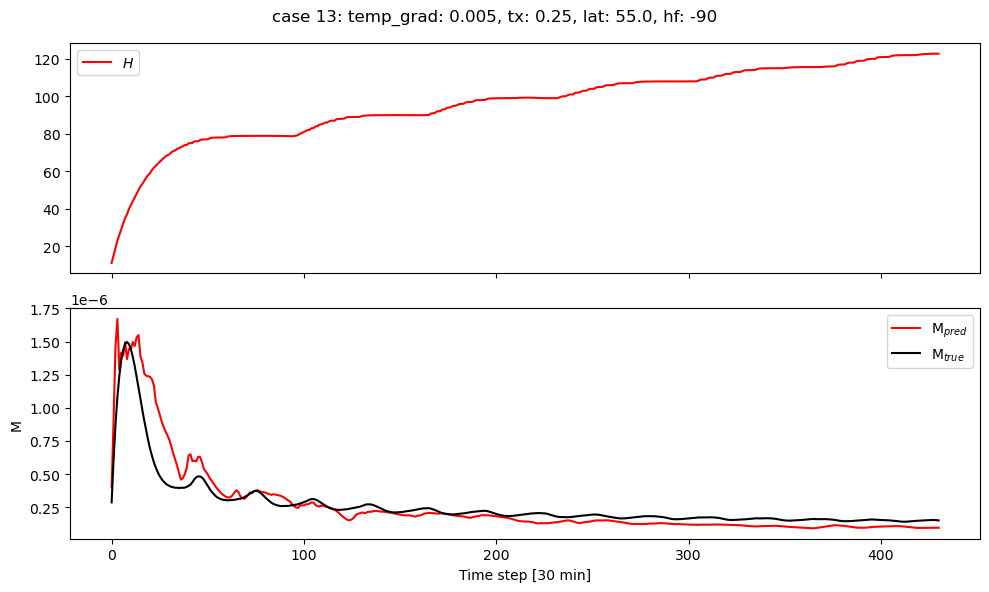

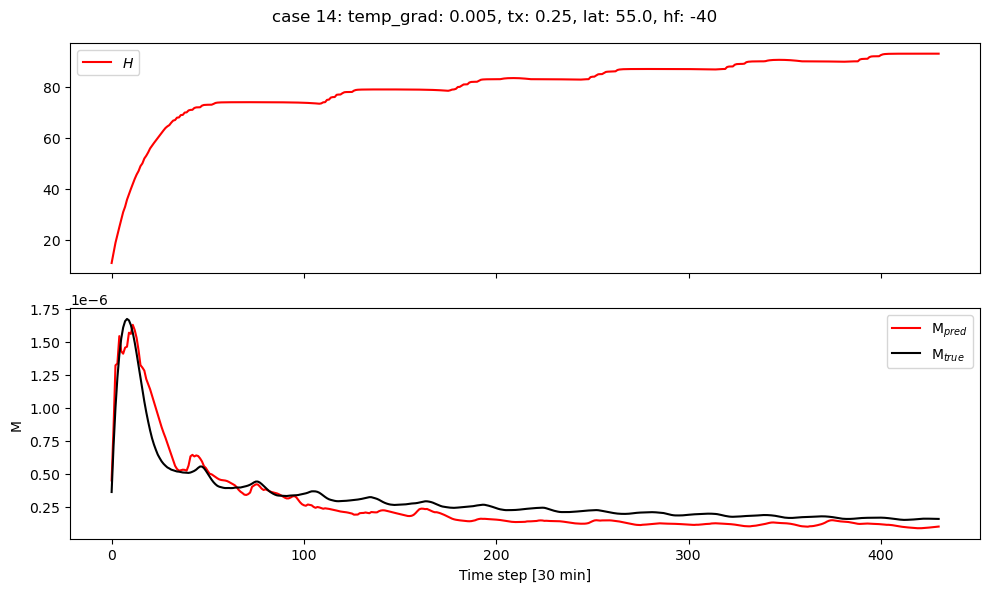

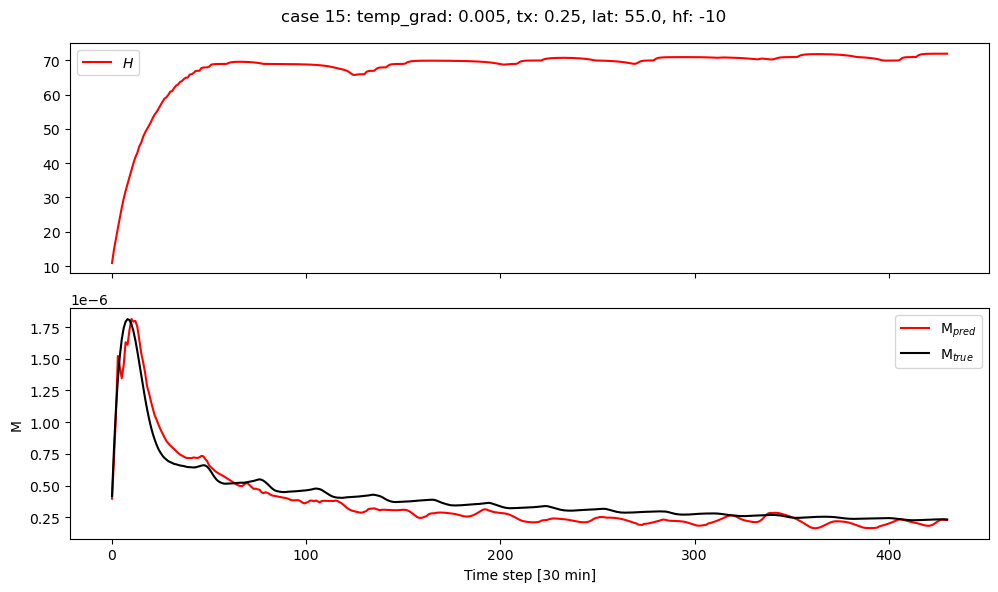

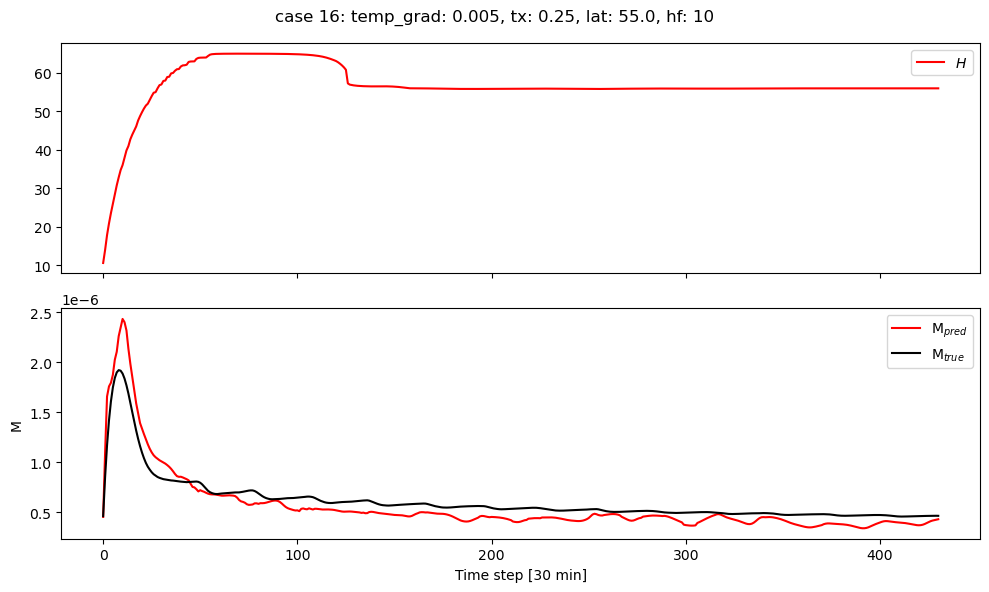

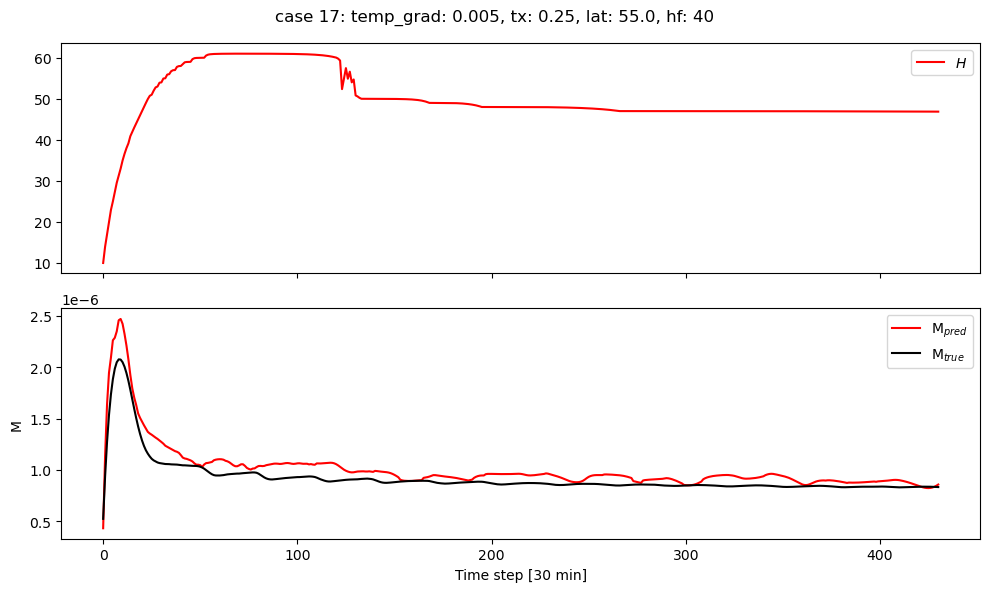

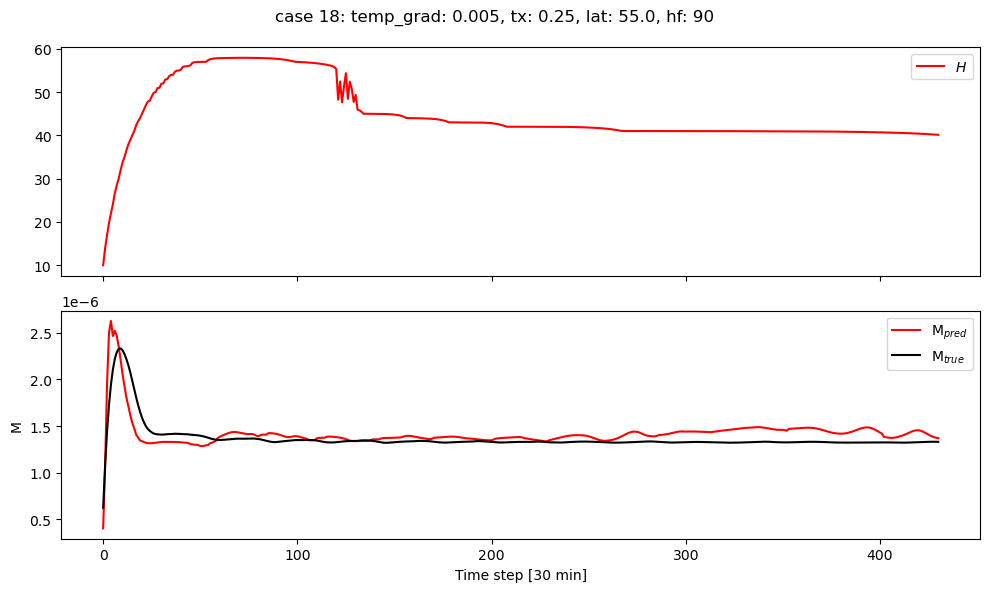

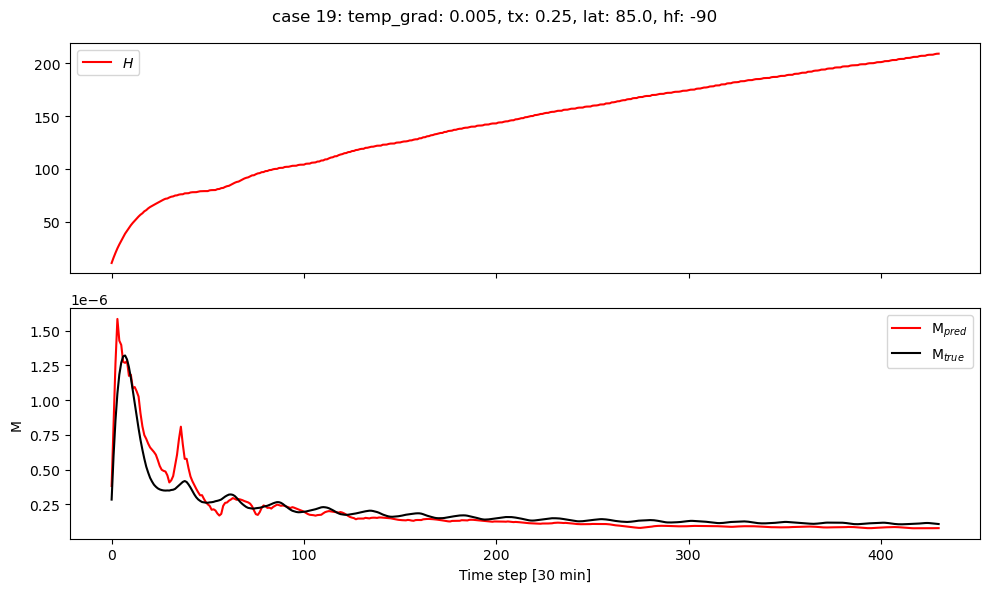

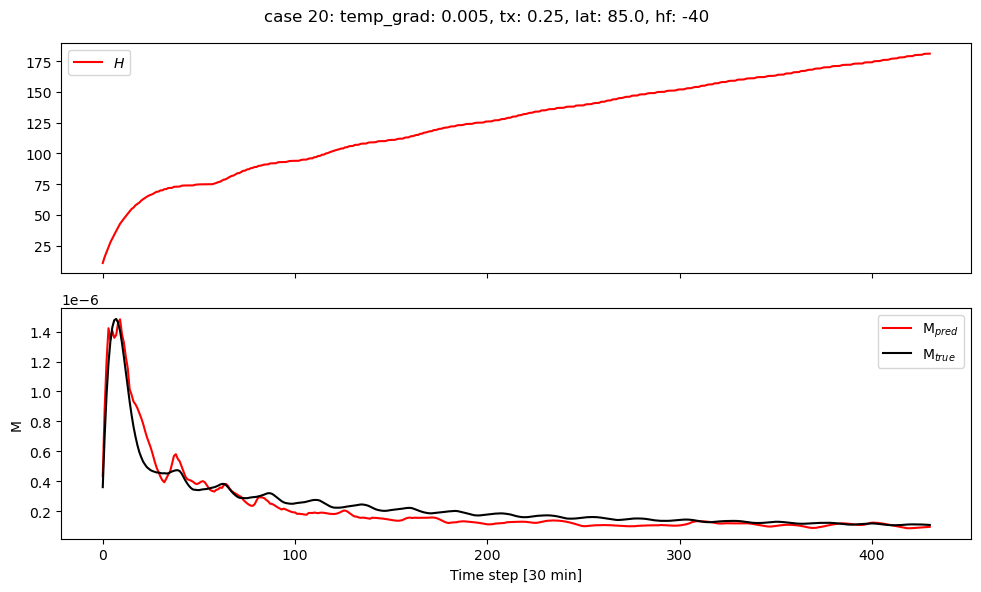

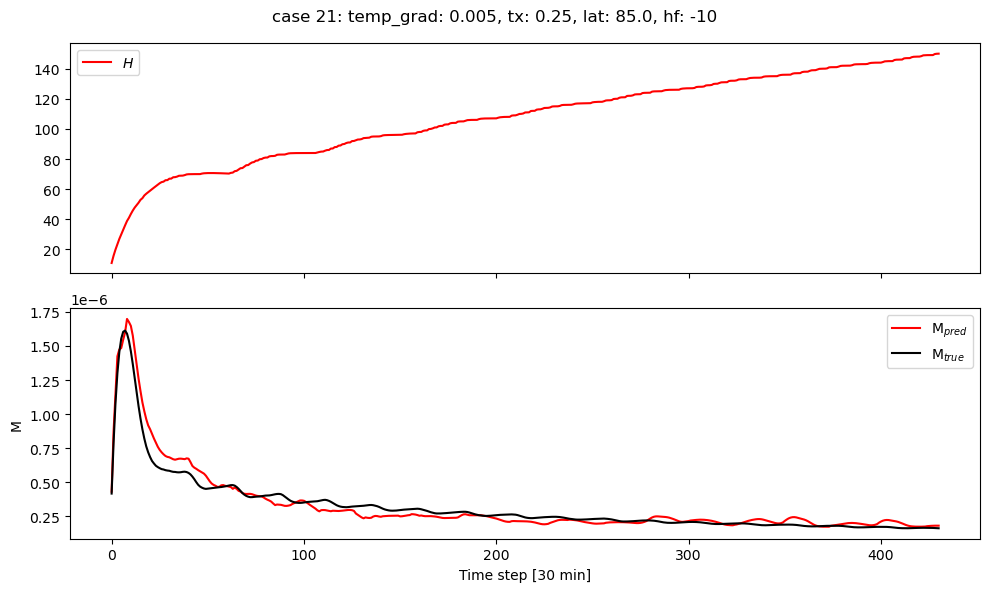

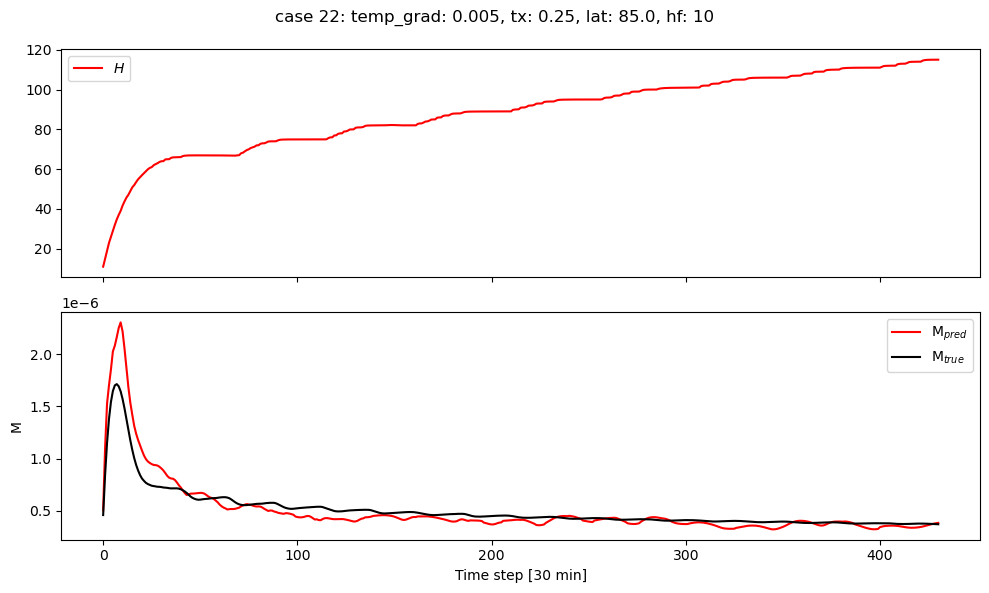

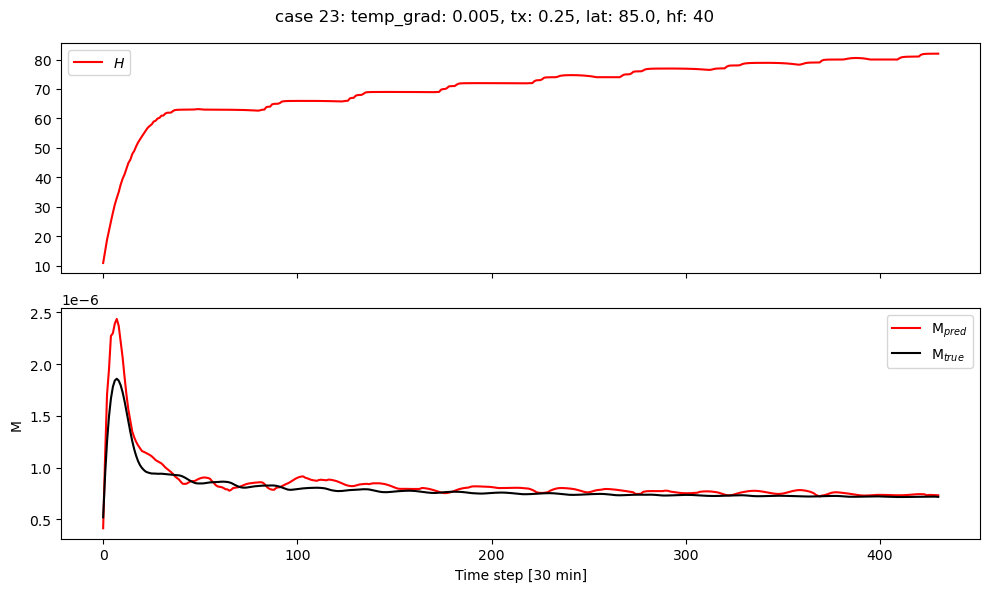

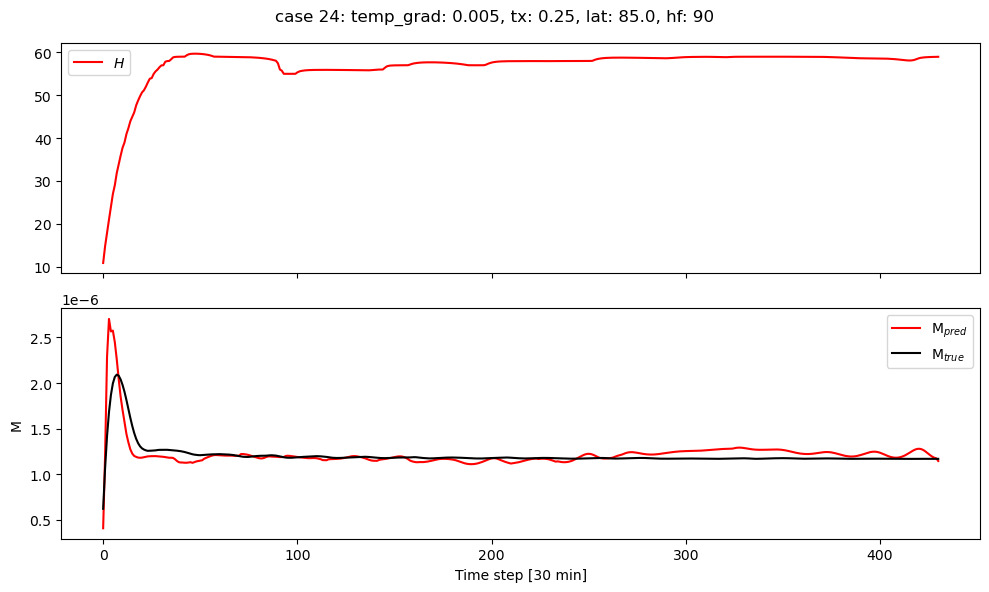

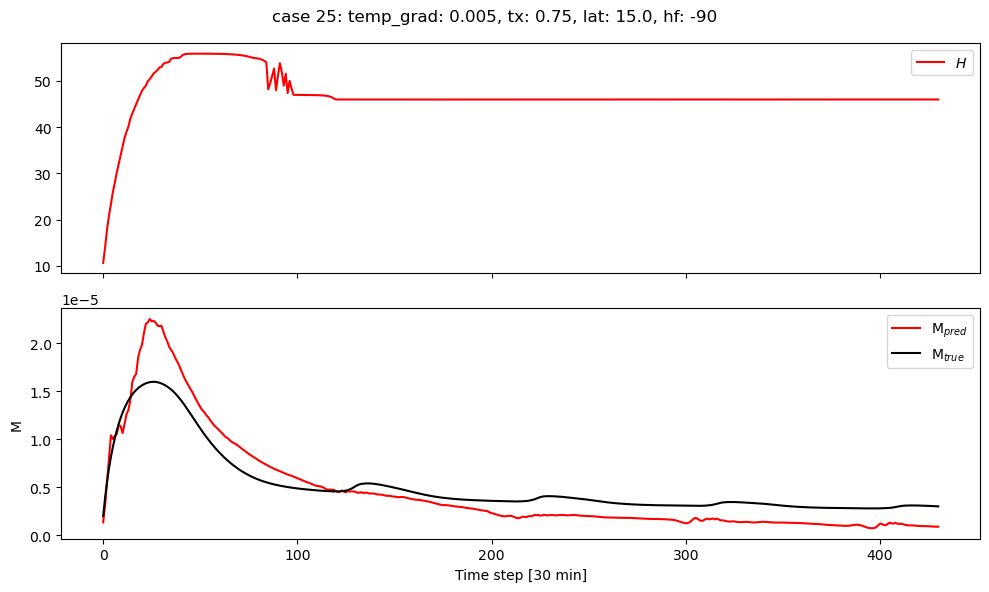

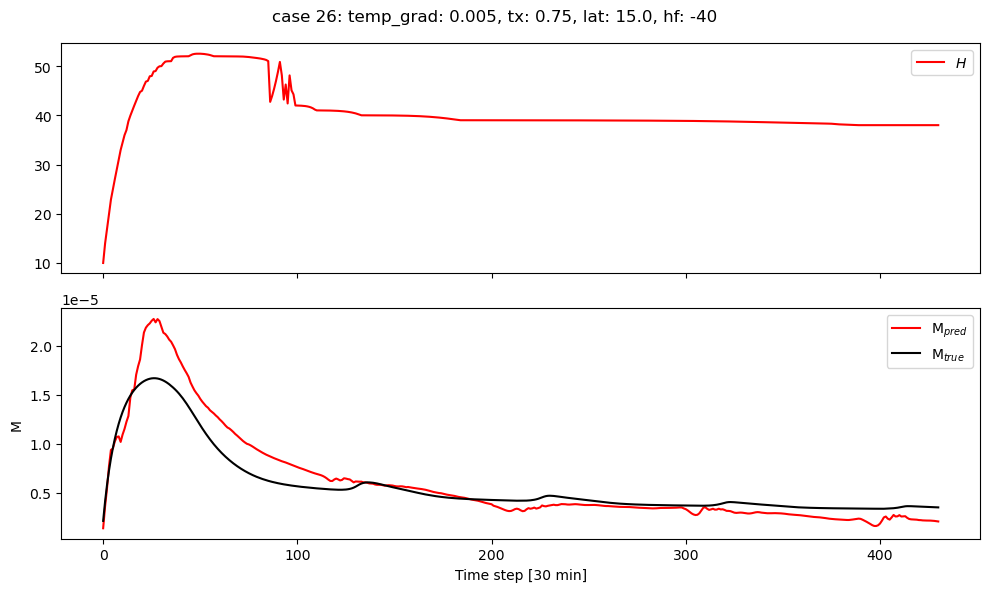

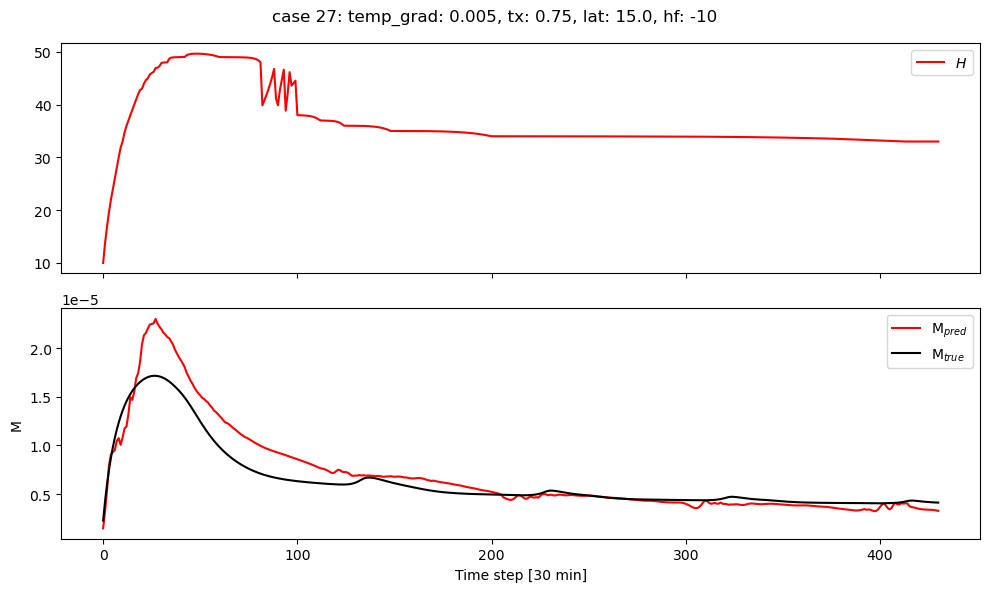

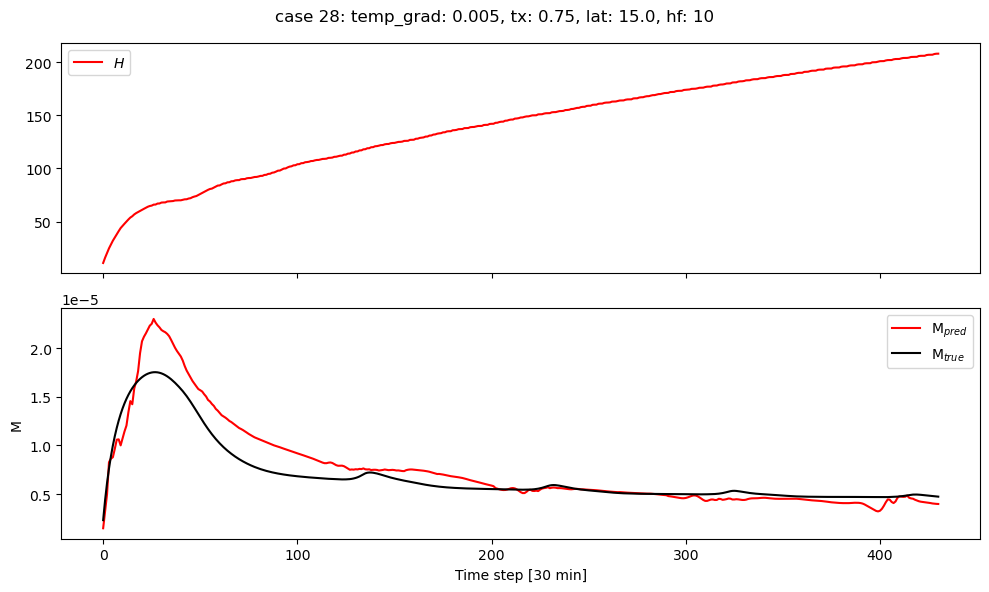

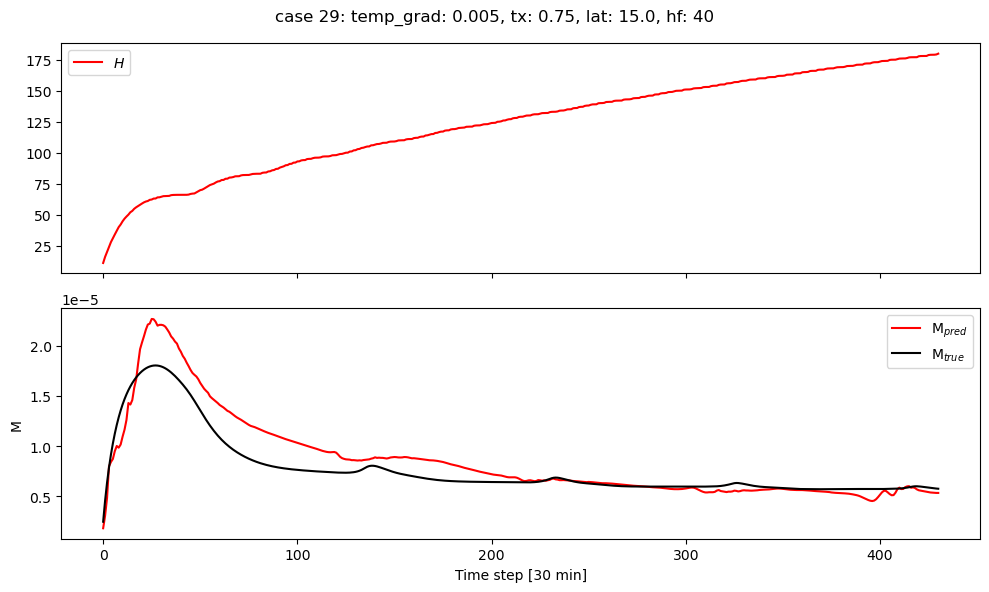

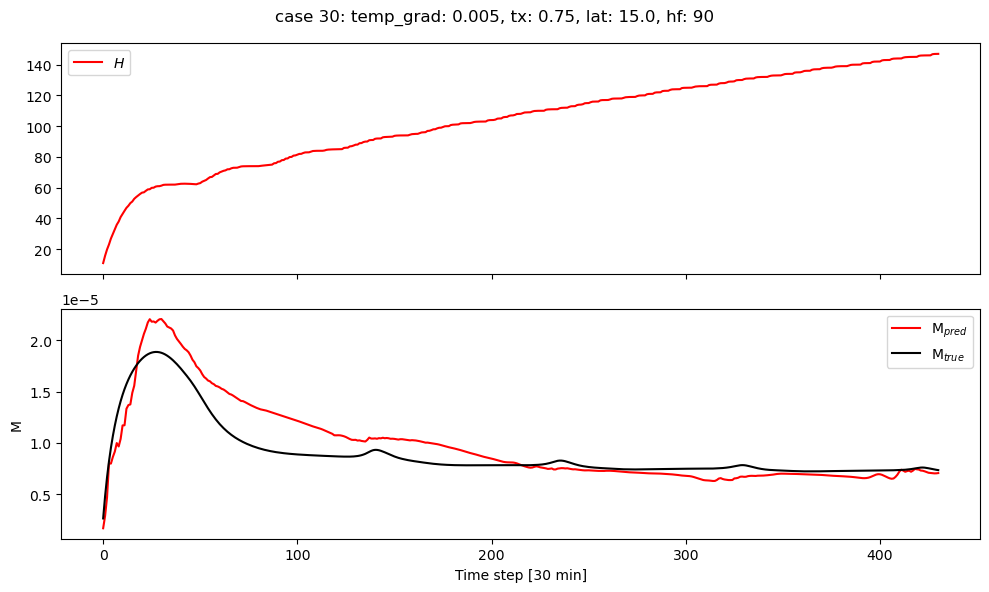

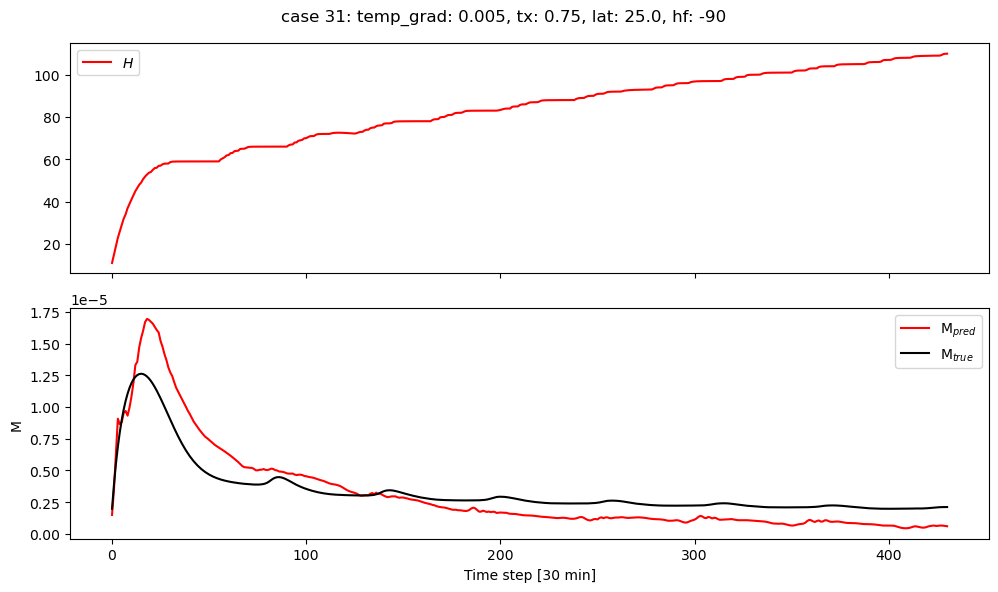

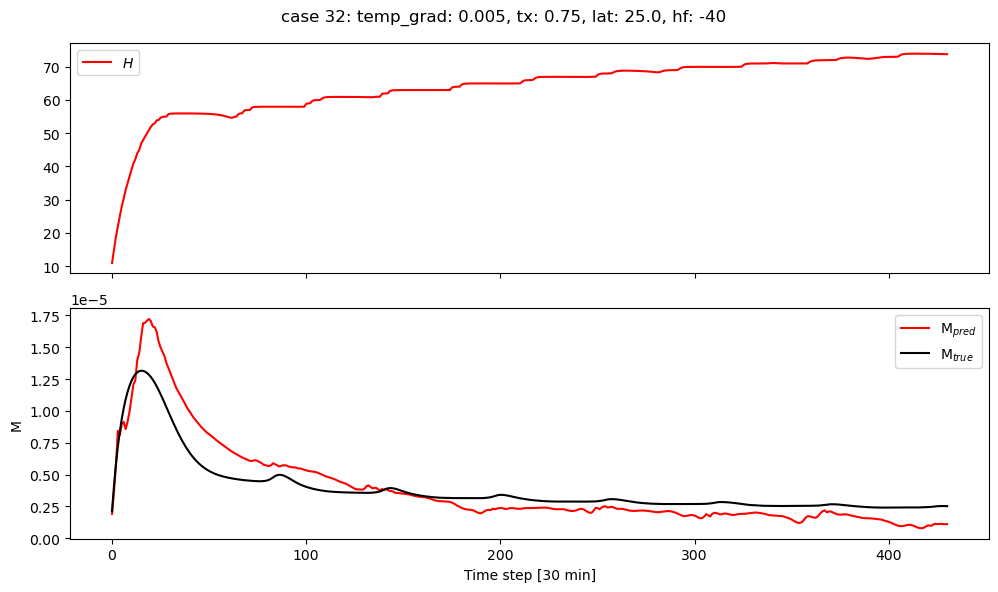

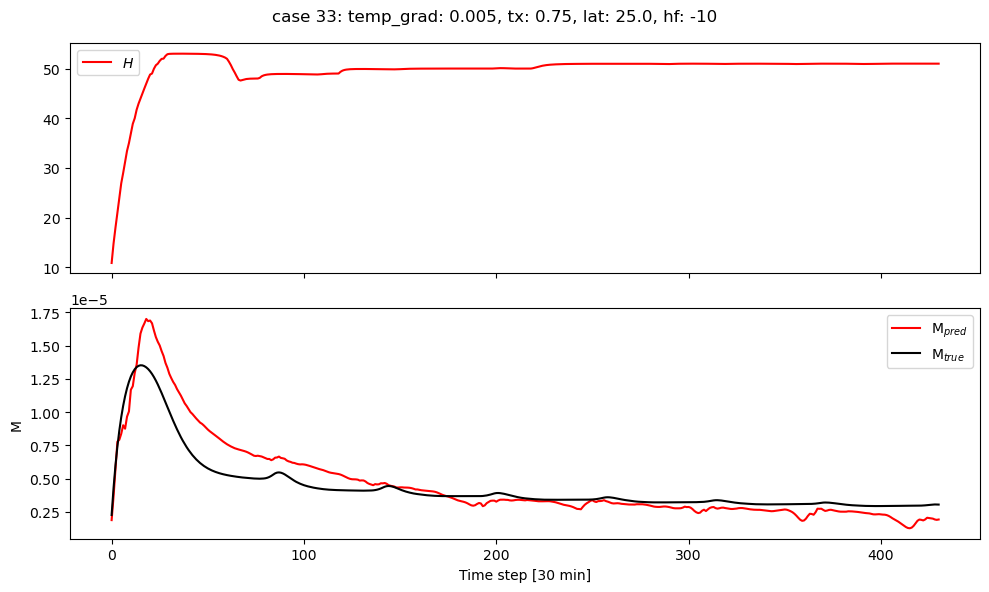

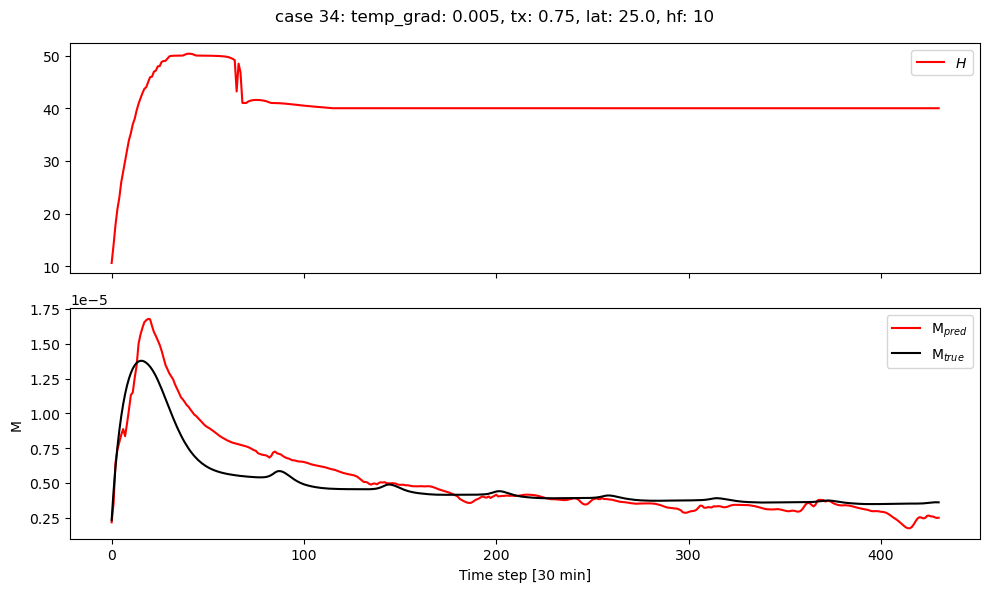

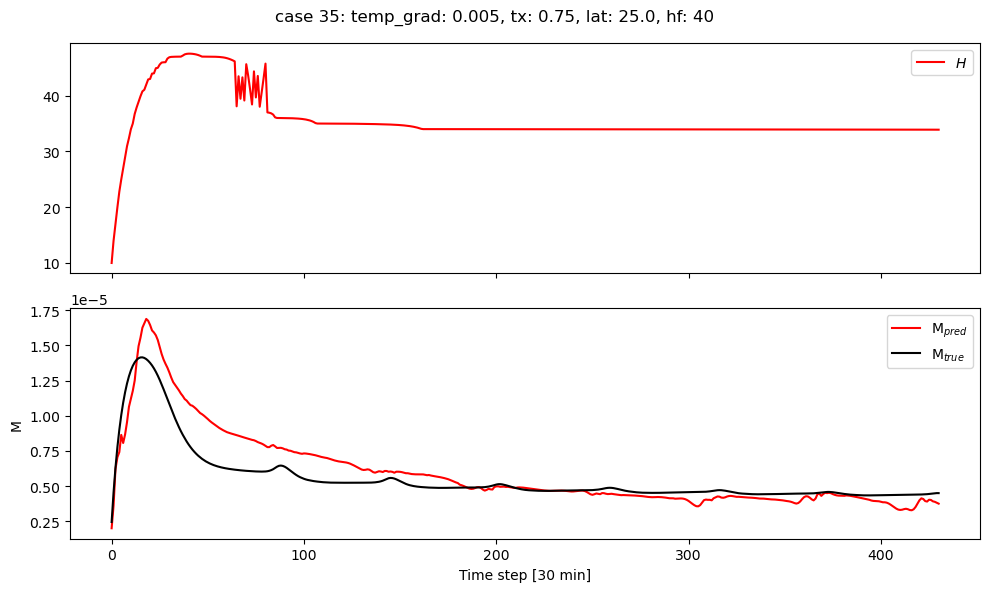

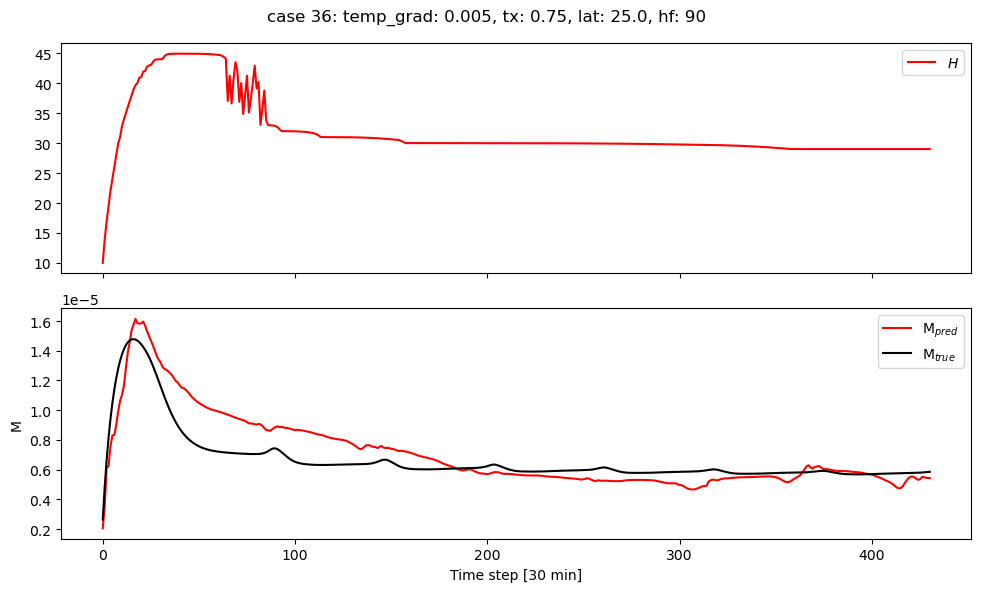

In [28]:
for i in range(0,36):
    case_specs = gotm_validation_case_dict[f"case_{i+1}"]
    tg, tx, lat, hf = case_specs['temp_grad'], case_specs['tx'], case_specs['lat'], case_specs['heat_flux']
    fig, ax = plt.subplots(2,1,figsize=(10,6),tight_layout=True,sharex=True)
    plt.suptitle(f"case {i+1}: temp_grad: {tg}, tx: {tx}, lat: {lat}, hf: {hf}")
    ax[0].plot(X.detach().numpy()[config.n_time_steps*i:config.n_time_steps*(i+1),0], label="$H$", color="red")
    ax[0].legend()
    ax[1].plot(fcnn_prediction_val.detach().numpy()[config.n_time_steps*i:config.n_time_steps*(i+1)], label="M$_{pred}$", color="red")
    ax[1].plot(y_val[config.n_time_steps*i:config.n_time_steps*(i+1)], label="M$_{true}$", color="black")
    ax[1].set_xlabel("Time step [30 min]")
    ax[1].set_ylabel("M")
    ax[1].legend()